# Accelerated Stability Study - Two Prototype Formulations
**Data analysis exercise**

This notebook analyses an accelerated stability study comparing two prototype formulations (Lot A014 / Formulation A and Lot B025 / Formulation B) of the same product. Samples were held at elevated temperature and humidity for varying periods, then assayed for active content and two degradation products.


**Headline conclusions:**
1. Temperature is the dominant driver of active-ingredient loss; at 70 °C the assay falls ~35 % from baseline by 3 weeks.
2. Time and temperature act *together* - a statistically significant temperature×time interaction is consistent with simple thermal degradation kinetics (apparent activation energy ≈ 100 kJ/mol).
3. Relative humidity has, at most, a weak secondary effect in this dataset and is partially confounded with the other factors.
4. Impurity RRT 1.23 behaves as a **transient intermediate** (it rises then falls), so it is not a clean monotonic shelf-life marker.
5. The two formulations are **very similar**; Formulation A is *marginally* better (slightly higher assay retention and lower Imp 1.23), but the difference is close to analytical noise and is not conclusive on this data alone.


## Setup and data loading

In [1]:
#Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
#Load the data (provide the excel file path here)
DATA_PATH = "KTP_task_datasets.xls"

In [3]:
#Understanding raw Excel(data) before any processing
raw_A = pd.read_excel(DATA_PATH, sheet_name="Lot A014", header=0)
raw_B = pd.read_excel(DATA_PATH, sheet_name="Lot B025", header=0)

print("Lot A014")
print("Shape:", raw_A.shape) #Display number of rows and columns
print(raw_A.head()) #Display the first few rows of the data

print("\n Lot B025")
print("Shape:", raw_B.shape)
print(raw_B.head())

Lot A014
Shape: (21, 14)
  Start Date  Pull Date  Set down day   length of exposure (days)    Oven  \
0        NaT        NaT            NaN                        NaN     NaN   
1 2025-12-18 2026-01-08            0.0                       21.0  Oven 2   
2 2025-12-18 2026-01-08            0.0                       21.0  Oven 4   
3 2025-12-18 2026-01-08            0.0                       21.0  Oven 1   
4 2025-12-18 2026-01-08            0.0                       21.0  Oven 3   

  T (° C)  %RH     Analyst Assay (mg/tablet) Unnamed: 9 Imp RRT 0.92 (%)  \
0     NaN  NaN  (initials)          sample 1   sample 2         sample 1   
1      70   11          RG             8.185      8.119            0.288   
2      65   25          SS            11.184     10.702            0.246   
3      50   64          SS              12.1     12.238            0.222   
4      60   80         CM             11.518     11.095            0.651   

  Unnamed: 11 IMP RRT 1.23 (%) Unnamed: 13  
0    Sampl

In [4]:
#Data summary
raw_A.info() #dtypes, non-null counts, memory
raw_A.isnull().sum() #missing values per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Start Date                 19 non-null     datetime64[ns]
 1   Pull Date                  19 non-null     datetime64[ns]
 2   Set down day               20 non-null     float64       
 3   length of exposure (days)  20 non-null     float64       
 4   Oven                       20 non-null     object        
 5   T (° C)                    20 non-null     object        
 6   %RH                        20 non-null     object        
 7   Analyst                    21 non-null     object        
 8   Assay (mg/tablet)          21 non-null     object        
 9   Unnamed: 9                 21 non-null     object        
 10  Imp RRT 0.92 (%)           21 non-null     object        
 11  Unnamed: 11                21 non-null     object        
 12  IMP RRT 1.

Start Date                   2
Pull Date                    2
Set down day                 1
length of exposure (days)    1
Oven                         1
T (° C)                      1
%RH                          1
Analyst                      0
Assay (mg/tablet)            0
Unnamed: 9                   0
Imp RRT 0.92 (%)             0
Unnamed: 11                  0
IMP RRT 1.23 (%)             0
Unnamed: 13                  0
dtype: int64

The spreadsheet has one sheet per lot and a **two-row header** (header name above a *sample 1 / sample 2* sub-header). The small loader below flattens that into tidy columns, coerces numerics, flags the unstressed **control** row (which stores the text `control` in its temperature/humidity fields), and adds the per-point replicate mean and spread. Keeping it as one function at the top of the notebook makes the whole analysis self-contained and reproducible.

In [5]:
#Data loading functions

LOT_TO_FORMULATION = {"Lot A014": "Formulation A", "Lot B025": "Formulation B"}
COLUMNS = ["start_date", "pull_date", "set_down_day", "exposure_days",
           "oven", "T_C", "RH", "analyst",
           "assay_s1", "assay_s2", "imp092_s1", "imp092_s2",
           "imp123_s1", "imp123_s2"]

def load_lot(path, sheet):
    """Read one lot sheet, flattening the two-row header into tidy columns."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    df = raw.iloc[2:].copy()              # rows 0-1 are the merged header
    df.columns = COLUMNS                  # assign the predefined column names to the DataFrame(df)
    df["lot"] = sheet                     # add a new column 'lot' and set its value to the current sheet name
    df["formulation"] = LOT_TO_FORMULATION[sheet]  # add a new column 'formulation' by mapping the sheet name
    return df.reset_index(drop=True)      # reset the df index, dropping the old index, and return the cleaned data frame

def load_all(path):
    """Load both lots, coerce numerics, flag the control, add replicate stats."""
    df = pd.concat([load_lot(path, "Lot A014"), load_lot(path, "Lot B025")],
                   ignore_index=True)

    # control row: literal text 'control' sits in the T / RH fields
    df["is_control"] = df["T_C"].astype(str).str.contains("control", case=False)

    numeric = ["set_down_day", "exposure_days", "T_C", "RH",
               "assay_s1", "assay_s2", "imp092_s1", "imp092_s2",
               "imp123_s1", "imp123_s2"]
    for col in numeric:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # replicate mean + absolute spread (a direct measure of analytical precision)
    for name, (a, b) in {"assay": ("assay_s1", "assay_s2"),
                         "imp092": ("imp092_s1", "imp092_s2"),
                         "imp123": ("imp123_s1", "imp123_s2")}.items():
        df[name] = df[[a, b]].mean(axis=1)
        df[f"{name}_spread"] = (df[a] - df[b]).abs()
    return df

df = load_all(DATA_PATH)
stressed = df[~df["is_control"]].copy()
control  = df[df["is_control"]].copy()
print(f"Rows total: {len(df)}  |  stressed: {len(stressed)}  |  control: {len(control)}")

Rows total: 40  |  stressed: 38  |  control: 2


## Q1 - What are the key features of the dataset?

**Structural points worth noting:**

- The **two-row header** is flattened above so every replicate has its own column.
- Each lot has **19 stressed conditions plus 1 control** (40 rows total). The two lots share the *same* 19 condition combinations, so this is a **paired design** - I will explain that in Q4.
- The **control row** is the unstressed *t = 0* reference; it must be excluded from numeric modelling (otherwise `control` corrupts the predictors).

In [6]:
#Checking stressed samples by formulation
print("Conditions per lot:")
print(stressed.groupby("formulation").size())
df.head()

Conditions per lot:
formulation
Formulation A    19
Formulation B    19
dtype: int64


,start_date,pull_date,set_down_day,exposure_days,oven,T_C,RH,analyst,assay_s1,assay_s2,...,imp123_s2,lot,formulation,is_control,assay,assay_spread,imp092,imp092_spread,imp123,imp123_spread
0,2025-12-18 00:00:00,2026-01-08 00:00:00,0,21,Oven 2,70.0,11.0,RG,8.185,8.119,...,0.074,Lot A014,Formulation A,False,8.1520,0.066,0.2850,0.006,0.074,0.000
1,2025-12-18 00:00:00,2026-01-08 00:00:00,0,21,Oven 4,65.0,25.0,SS,11.184,10.702,...,0.136,Lot A014,Formulation A,False,10.9430,0.482,0.2305,0.031,0.135,0.002
2,2025-12-18 00:00:00,2026-01-08 00:00:00,0,21,Oven 1,50.0,64.0,SS,12.100,12.238,...,0.189,Lot A014,Formulation A,False,12.1690,0.138,0.2220,0.000,0.190,0.002
3,2025-12-18 00:00:00,2026-01-08 00:00:00,0,21,Oven 3,60.0,80.0,CM,11.518,11.095,...,0.171,Lot A014,Formulation A,False,11.3065,0.423,0.6620,0.022,0.169,0.004
4,2025-12-18 00:00:00,2026-01-08 00:00:00,0,21,Oven 3,60.0,42.0,CM,11.813,11.294,...,0.176,Lot A014,Formulation A,False,11.5535,0.519,0.5340,0.014,0.176,0.000


**The experimental design:** Every sample was *pulled* on roughly the same date but *set down* on different dates, producing a spread of exposure durations (1–21 days) all read out together. I check the oven --> temperature --> humidity mapping carefully.

In [7]:
print("Temperature levels (°C):", sorted(stressed['T_C'].dropna().unique()))
print("Exposure durations (days):", sorted(stressed['exposure_days'].dropna().unique()))
print("\nOven -> Temperature (clean 1:1 mapping):")
print(stressed.groupby('oven')['T_C'].unique())
print("\nOven -> RH (RH VARIES within an oven -> not a fixed-RH chamber design):")
print(stressed.groupby('oven')['RH'].apply(lambda x: sorted(x.dropna().unique())))

Temperature levels (°C): [50.0, 60.0, 65.0, 70.0]
Exposure durations (days): [1, 2, 5, 6, 7, 14, 17, 19, 20, 21]

Oven -> Temperature (clean 1:1 mapping):
oven
Oven 1    [50.0]
Oven 2    [70.0]
Oven 3    [60.0]
Oven 4    [65.0]
Name: T_C, dtype: object

Oven -> RH (RH VARIES within an oven -> not a fixed-RH chamber design):
oven
Oven 1                [64.0]
Oven 2    [11.0, 41.0, 79.0]
Oven 3    [21.0, 42.0, 80.0]
Oven 4          [25.0, 63.0]
Name: RH, dtype: object


**Analysis from above:** Oven number maps clearly to a single temperature (Oven 1 = 50 °C, 3 = 60 °C, 4 = 65 °C, 2 = 70 °C). Humidity, however, takes several values *within* the same oven, so RH was varied as a separate factor and
the design is **not** a tidy factorial of fixed T/RH chambers. This matters: temperature is a clean, well-replicated factor, whereas RH is sparser and partially confounded.

In [8]:
# Data quality - missing values and replicate precision:

print("Missing values:")
print(df.isna().sum()[lambda s: s > 0], "\n")
# the only NaNs are the control's T/RH/date fields, which is expected

print("Replicate precision — mean |sample1 - sample2|:")
print(stressed[['assay_spread','imp092_spread','imp123_spread']].mean().round(4))

Missing values:
start_date    2
pull_date     2
T_C           2
RH            2
dtype: int64 

Replicate precision — mean |sample1 - sample2|:
assay_spread     0.2185
imp092_spread    0.0201
imp123_spread    0.0033
dtype: float64


**Observation:** The replicates agree very closely (Imp 1.23 spread ≈ 0.003 %, assay ≈ 0.22 mg/tablet), so the analytical method is precise and any effect larger than this is real signal rather than measurement noise.

In [9]:
#Baseline (control) values

control[['lot','formulation','assay','imp092','imp123']]

,lot,formulation,assay,imp092,imp123
19,Lot A014,Formulation A,12.7990,0.0,0.075
39,Lot B025,Formulation B,12.6065,0.0,0.143


## Q2 - What insights can be gained from the available data?

How does the active assay change with exposure, and how does temperature separate the conditions?

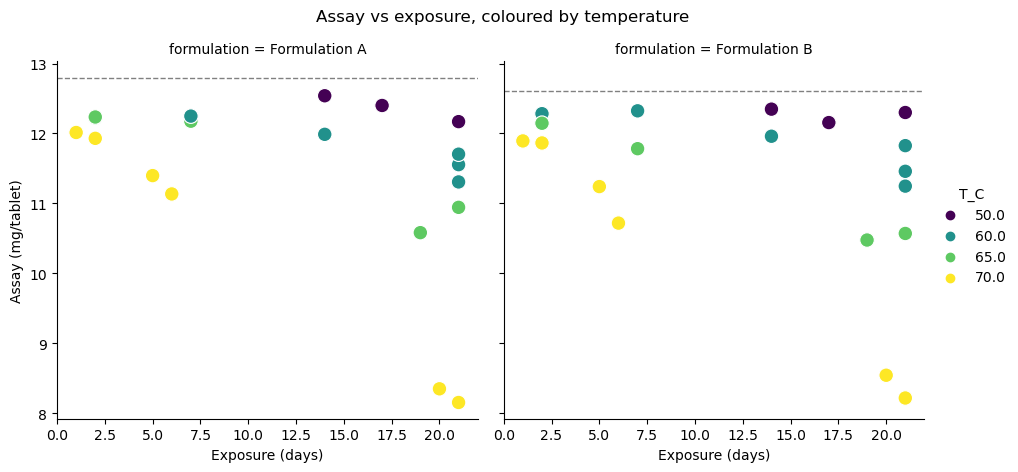

In [10]:
#Plot assay vs. exposure for stressed samples by formulation, overlaid with control baseline

base_assay = control.groupby('lot')['assay'].mean()

g = sns.relplot(data=stressed, x='exposure_days', y='assay', hue='T_C',
                col='formulation', palette='viridis', s=110, height=4.5, aspect=1.05)
g.set_axis_labels('Exposure (days)', 'Assay (mg/tablet)')
g.fig.suptitle('Assay vs exposure, coloured by temperature', y=1.04)
for ax, lot in zip(g.axes.flat, base_assay.index):
    ax.axhline(base_assay[lot], ls='--', c='grey', lw=1)
plt.show()

**What this shows:** The points fan out by colour (temperature): the hottest condition (70 °C, yellow) sits well below the cooler ones, and the gap widens at longer exposures. Cooler conditions stay close to the dashed baseline. The plot reveals that temperature accelerates degradation, with the effect intensifying over time - this relationship will be quantified in the next section.

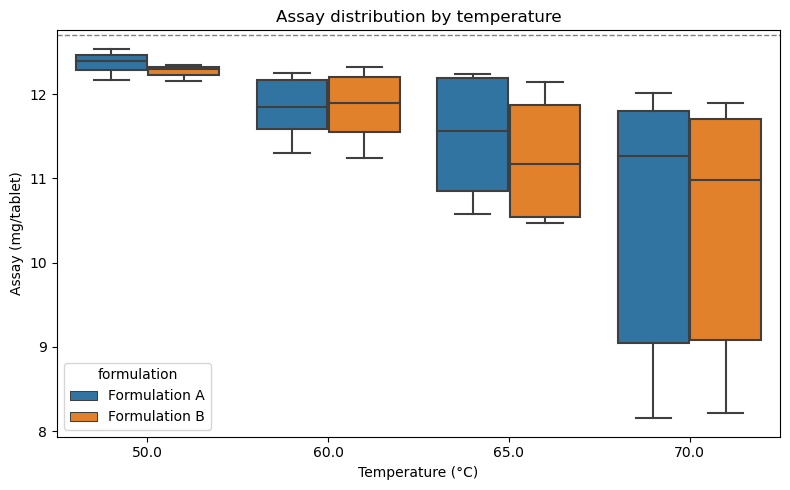

Mean assay at >= 17 days exposure, by temperature:
T_C
50.0    12.26
60.0    11.52
65.0    10.64
70.0     8.31
Name: assay, dtype: float64


In [11]:
#Displaying effect of temperature on assay retention under accelerated stability conditions

plt.figure(figsize=(8,5))
sns.boxplot(data=stressed, x='T_C', y='assay', hue='formulation')
plt.axhline(base_assay.mean(), ls='--', c='grey', lw=1)
plt.xlabel('Temperature (°C)'); plt.ylabel('Assay (mg/tablet)')
plt.title('Assay distribution by temperature'); plt.tight_layout(); plt.show()

print("Mean assay at >= 17 days exposure, by temperature:")
print(stressed[stressed['exposure_days'] >= 17].groupby('T_C')['assay'].mean().round(2))

**Observation:** At long exposure the mean assay drops monotonically with temperature (≈12.3 → 11.5 → 10.6 → 8.3 mg/tablet across 50→60→65→70 °C). The 70 °C condition represents roughly a third of the active ingredient lost.

## Q3 - What factors appear to influence product degradation?

Separate the contributions of temperature, time and humidity.

In [12]:
#Checking correlation among variables

print("Correlations among design variables (confounding check):")
print(stressed[['T_C','RH','exposure_days']].corr().round(2))

Correlations among design variables (confounding check):
                T_C    RH  exposure_days
T_C            1.00 -0.27          -0.36
RH            -0.27  1.00          -0.23
exposure_days -0.36 -0.23           1.00


**Comment:** The design variables are only mildly correlated, but RH is weakly *negatively* correlated with both temperature and exposure i.e. not fully independent. This point should be noted when interpreting the RH coefficient.

In [13]:
#Regression analysis of factors associated with product degradation

fit_df = stressed.dropna(subset=['assay','T_C','RH','exposure_days']).copy()

m_main = smf.ols('assay ~ T_C + exposure_days + RH + C(formulation)', data=fit_df).fit()
m_int  = smf.ols('assay ~ T_C * exposure_days + RH + C(formulation)', data=fit_df).fit()

print("Main-effects model — adj R2 =", round(m_main.rsquared_adj, 3))
print(m_main.params.round(4), "\n")
print("With temperature x time interaction — adj R2 =", round(m_int.rsquared_adj, 3))
print(m_int.params.round(4))
print("\nInteraction term p-value:", round(m_int.pvalues['T_C:exposure_days'], 4))

Main-effects model — adj R2 = 0.741
Intercept                          22.2676
C(formulation)[T.Formulation B]    -0.0893
T_C                                -0.1474
exposure_days                      -0.1134
RH                                 -0.0035
dtype: float64 

With temperature x time interaction — adj R2 = 0.807
Intercept                          14.9568
C(formulation)[T.Formulation B]    -0.0893
T_C                                -0.0347
exposure_days                       0.3851
T_C:exposure_days                  -0.0077
RH                                 -0.0056
dtype: float64

Interaction term p-value: 0.0014


**Evidence and interpretation:**

- **Temperature** has the largest, most reliable effect: every +1 °C is associated with measurable assay loss.
- **Time** matters too, and the **temperature×time interaction is significant (p ≈ 0.001)**, raising adjusted R² from ~0.74 to ~0.81. Mechanistically this is exactly what thermally-activated degradation predicts: heat and duration compound rather than add.
- **Humidity** carries a small coefficient and, given its confounding and sparser coverage, No claim for a firm RH effect from this dataset.

**Limitations:** Only four temperatures and a single combined pull date limit the resolution of the time axis at each temperature; RH is not cleanly crossed with temperature. So these coefficients are descriptive associations, not validated kinetic constants.

**More observations - a caution:** Plotting Imp 1.23 over time at 70 °C reveals it is *not* a simple accumulating marker.

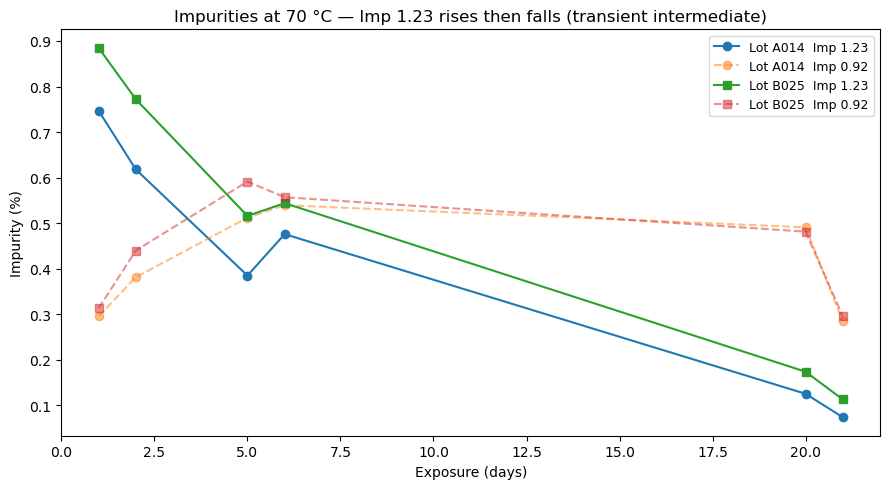

In [14]:
#Ploting comparison of Impurity growth kinetics between Formulations at 70°C

plt.figure(figsize=(9,5))
for lot, mk in zip(['Lot A014','Lot B025'], ['o','s']):
    sub = stressed[(stressed['T_C']==70) & (stressed['lot']==lot)].sort_values('exposure_days')
    plt.plot(sub['exposure_days'], sub['imp123'], mk+'-', label=f'{lot}  Imp 1.23')
    plt.plot(sub['exposure_days'], sub['imp092'], mk+'--', alpha=.5, label=f'{lot}  Imp 0.92')
plt.xlabel('Exposure (days)'); plt.ylabel('Impurity (%)')
plt.title('Impurities at 70 °C — Imp 1.23 rises then falls (transient intermediate)')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

**Observation:** Imp 1.23 is highest at short exposures and *declines* by day 20–21, while the assay keeps falling. The most plausible reading is that Imp 1.23 is a **transient intermediate** that itself degrades onward - so a naive "impurity grows with time" model would be misleading, and a regression of Imp 1.23 on time alone shows a
spurious negative slope. This feature should shape, not be hidden by, the modelling choice.

## Q4 - How would you describe the relative performance of the two prototype formulations?


In [15]:
#Evaluate relative formulation performance by comparing assay and impurity levels 
# within matched stability-study conditions (exposure time, temperature, and relative humidity).

key = ['exposure_days','T_C','RH']    # variables defining a unique storage condition
a = stressed[stressed['lot']=='Lot A014'].set_index(key)[['assay','imp092','imp123']] 
b = stressed[stressed['lot']=='Lot B025'].set_index(key)[['assay','imp092','imp123']] 

# Join the two DataFrames on the index (inner join) to keep only matching (exposure_days, T_C, RH) combinations,
# adding '_A' and '_B' suffixes to distinguish columns from the two lots
paired = a.join(b, lsuffix='_A', rsuffix='_B', how='inner') 

print(f"Matched conditions: {len(paired)}\n")
for v, better in [('assay','higher=better'),('imp092','lower=better'),('imp123','lower=better')]:
    d = paired[f'{v}_A'] - paired[f'{v}_B']
    print(f"{v:7s} mean(A-B) = {d.mean():+.3f}   ({better})")

Matched conditions: 19

assay   mean(A-B) = +0.089   (higher=better)
imp092  mean(A-B) = -0.019   (lower=better)
imp123  mean(A-B) = -0.101   (lower=better)


**Comment 1:** On matched conditions Formulation A is *marginally* preferable: it retains slightly more active ingredient (mean assay ≈ +0.09 mg/tablet) and shows a little less Imp1.23 (≈ −0.10 %). Imp0.92 is essentially
tied.

**Comment 2:** The assay difference (~ 0.09 mg) is of the same order as the replicate spread (~ 0.22 mg)(from cell 8), so it sits close to the noise floor and could reverse with more data. The defensible conclusion is: *the two formulations are broadly comparable; the evidence leans slightly toward A but is not strong enough to be decisive.* This study alone does not justify rejecting Formulation B.

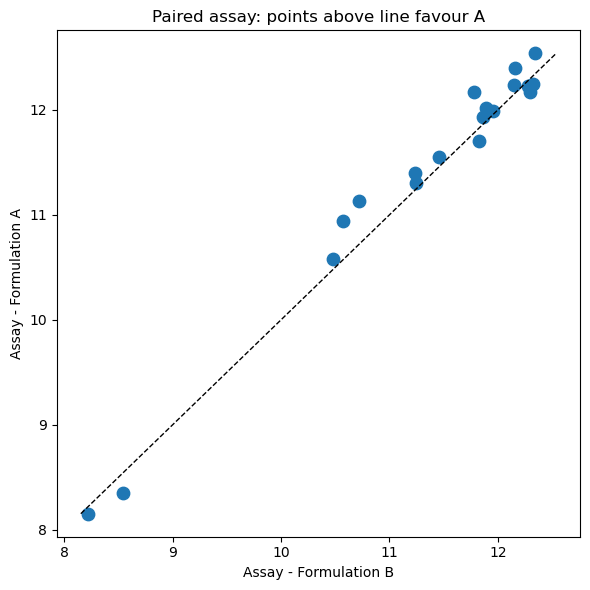

In [16]:
#Plot paired assay comparison: Formulation A vs B with diagonal reference line

plt.figure(figsize=(6,6))
mx = max(paired['assay_A'].max(), paired['assay_B'].max())
mn = min(paired['assay_A'].min(), paired['assay_B'].min())
plt.scatter(paired['assay_B'], paired['assay_A'], s=80)
plt.plot([mn,mx],[mn,mx],'k--',lw=1)
plt.xlabel('Assay - Formulation B'); plt.ylabel('Assay - Formulation A')
plt.title('Paired assay: points above line favour A'); plt.tight_layout(); plt.show()

## Q5 - What additional insights can be obtained through modelling?

The dataset is small (~38 stressed points/lot) and well-structured, so the right modelling is **mechanistic and parsimonious**, not a flexible black box. Over-fitting a random forest or neural network here would be inappropriate and hard to interpret. Below are the two approaches:

**Model 1 - Interpretable linear model with interaction** (built in Q3): gives direction and relative magnitude of each factor, with the temperature x time interaction capturing the compounding effect. *Strength:* transparent and
defensible. *Limitation:* linear, so only valid over the studied range.

**Model 2 - Arrhenius framing.** Long-exposure data (≥17 days) were used to examine the relationship between storage temperature and the rate of assay degradation, providing an estimate of the temperature sensitivity of the degradation process.

Apparent activation energy  Ea ≈ 105 kJ/mol   (R2 = 0.94)


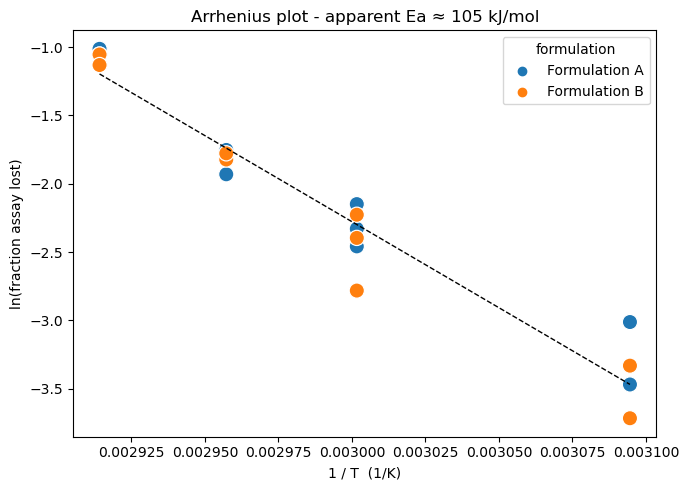

In [17]:
#Estimating the thermal sensitivity of the degradation process

R = 8.314   # Universal gas constant
le = fit_df[fit_df['exposure_days'] >= 17].copy()
le['frac_lost'] = 1 - le['assay'] / le['formulation'].map(
    {'Formulation A': base_assay['Lot A014'], 'Formulation B': base_assay['Lot B025']})
le = le[le['frac_lost'] > 0].copy()
le['invT'] = 1.0 / (le['T_C'] + 273.15)
le['ln_loss'] = np.log(le['frac_lost'])

arr = smf.ols('ln_loss ~ invT', data=le).fit()
Ea = -arr.params['invT'] * R / 1000
print(f"Apparent activation energy  Ea ≈ {Ea:.0f} kJ/mol   (R2 = {arr.rsquared:.2f})")

plt.figure(figsize=(7,5))
sns.scatterplot(data=le, x='invT', y='ln_loss', hue='formulation', s=120)
xx = np.linspace(le['invT'].min(), le['invT'].max(), 50)
plt.plot(xx, arr.params['Intercept'] + arr.params['invT']*xx, 'k--', lw=1)
plt.xlabel('1 / T  (1/K)'); plt.ylabel('ln(fraction assay lost)')
plt.title(f'Arrhenius plot - apparent Ea ≈ {Ea:.0f} kJ/mol')
plt.tight_layout(); plt.show()

**Why this is the right model:** An apparent activation energy near ~100 kJ/mol is physically reasonable for pharmaceutical degradation and, in a full study, would let the team *extrapolate* accelerated data to predict shelf life at ambient storage, the real business question behind the brief.

**Strengths:** interpretable, grounded in established stability science, few parameters (well-suited to a small dataset), and it produces a quantity (`Ea`) the development team can act on.

**Limitations:** with samples pulled at a single date, RH not cleanly crossed, and few replicates per temperature, this is a *proof-of-concept* fit. The confidenceinterval on `Ea` is wide, and a proper analysis would fit degradation **kinetics over true time courses** at each fixed temperature/humidity (e.g. first-order assay
loss --> rate constants --> Arrhenius), ideally in a single non-linear or Bayesian hierarchical model that pools the two lots.

## Q6 - What are the limitations of the dataset and how could future studies be improved?

**Limitations of the current dataset:**

1. **Single pull date**, all samples were read out together, so "exposure days" spans the set-down schedule rather than a true multi-timepoint course at each condition. This limits kinetic resolution and creates mild confounding between time, temperature and RH.
2. **Humidity not cleanly crossed with temperature**, and sparser than temperature, so RH effects cannot be separated reliably.
3. **Small N** (≈19 conditions/lot, duplicate measurements) - adequate for descriptive trends, thin for robust modelling or significance on the formulation difference.
4. **Imp 1.23 is transient**, so total mass-balance / degradation pathway is not captured by tracking it alone.
5. **No replicate ovens / batches**, so oven-to-oven and batch effects are indistinguishable from condition effects.

**Key priorities for further study (in order):**

1. **Proper time-course sampling** - multiple pull points (e.g. 0/1/2/4/8/12 weeks) at each fixed T and RH, enabling genuine first-order kinetic fits and a well-constrained Arrhenius/Eyring extrapolation to ambient shelf life.
2. **A clean TxRH factorial** at fixed setpoints to resolve the humidity effect.
3. **Mass-balance tracking** of all degradation products (not just two RRTs) to understand the Imp1.23 transient and total degradation.
4. **More replication / multiple batches** to quantify analytical vs batch variability and give the formulation comparison statistical power.
5. **A unified hierarchical kinetic model** pooling both lots, propagating uncertainty into the shelf-life prediction - the deliverable the business ultimately needs.

*Reproducibility note: This notebook is fully self-contained. To reproduce the analysis, rerun the notebook from top to bottom with the `.xls` data file located in the same directory.*